<a href="https://colab.research.google.com/github/Siew-116/EchoCalm/blob/master/grass_seg_unet_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

In [3]:
img_zip_path = "/content/drive/MyDrive/split_3.zip"

with zipfile.ZipFile(img_zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [4]:
# Import library
import tensorflow as tf
import keras
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from tensorflow import data  as tf_data
from tensorflow import image as tf_image
from tensorflow import io    as tf_io
from keras import layers, Model
import keras.backend as K

In [7]:
# Configuration
BASE_DIR        = "/content/dataset/split_3"
TRAIN_IMAGE_DIR = os.path.join(BASE_DIR, "train", "images")
TRAIN_MASK_DIR  = os.path.join(BASE_DIR, "train", "masks")
VAL_IMAGE_DIR   = os.path.join(BASE_DIR, "val",   "images")
VAL_MASK_DIR    = os.path.join(BASE_DIR, "val",   "masks")
TEST_IMAGE_DIR  = os.path.join(BASE_DIR, "test",  "images")
TEST_MASK_DIR   = os.path.join(BASE_DIR, "test",  "masks")

MODEL_DIR       = "/content/grass-seg/models"
LOG_DIR         = "/content/grass-seg/logs"
RESULT_DIR      = "/content/grass-seg/results"

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(LOG_DIR,    exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

# ---- Model config ----
IMG_SIZE    = (128, 128)
NUM_CLASSES = 4
BATCH_SIZE  = 32
EPOCHS      = 20
SEED        = 42

CLASS_NAMES = {
    0: "background",
    1: "grass_short",
    2: "grass_medium",
    3: "grass_long"
}

print("Configuration ready")
print(f"  Image size   : {IMG_SIZE}")
print(f"  Num classes  : {NUM_CLASSES}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Epochs       : {EPOCHS}")

Configuration ready
  Image size   : (128, 128)
  Num classes  : 4
  Batch size   : 32
  Epochs       : 20


In [8]:
# Verify data
print("Verifying data...")
for name, img_dir, mask_dir in [
    ("Train", TRAIN_IMAGE_DIR, TRAIN_MASK_DIR),
    ("Val",   VAL_IMAGE_DIR,   VAL_MASK_DIR),
    ("Test",  TEST_IMAGE_DIR,  TEST_MASK_DIR),
]:
    n_img  = len(os.listdir(img_dir))
    n_mask = len(os.listdir(mask_dir))
    match  = "OK" if n_img == n_mask else "MISMATCH"
    print(f"  {name:<6} images: {n_img:>5}  masks: {n_mask:>5}  [{match}]")

Verifying data...
  Train  images:  4796  masks:  4796  [OK]
  Val    images:   600  masks:   600  [OK]
  Test   images:   600  masks:   600  [OK]


In [9]:
def get_path_pairs(image_dir, mask_dir):
    image_files = sorted(os.listdir(image_dir))
    img_paths   = []
    mask_paths  = []
    missing     = []

    for img_file in image_files:
        stem      = os.path.splitext(img_file)[0]
        mask_file = stem + ".png"
        img_path  = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir,  mask_file)

        if os.path.exists(mask_path):
            img_paths.append(img_path)
            mask_paths.append(mask_path)
        else:
            missing.append(img_file)

    print(f"  Pairs: {len(img_paths)}  Missing: {len(missing)}")
    return img_paths, mask_paths

print("Building path pairs...")
train_img_paths,  train_mask_paths  = get_path_pairs(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)
val_img_paths,    val_mask_paths    = get_path_pairs(VAL_IMAGE_DIR,   VAL_MASK_DIR)
test_img_paths,   test_mask_paths   = get_path_pairs(TEST_IMAGE_DIR,  TEST_MASK_DIR)

print(f"\nTrain : {len(train_img_paths)}")
print(f"Val   : {len(val_img_paths)}")
print(f"Test  : {len(test_img_paths)}")

Building path pairs...
  Pairs: 4796  Missing: 0
  Pairs: 600  Missing: 0
  Pairs: 600  Missing: 0

Train : 4796
Val   : 600
Test  : 600


In [10]:
def augmentation(image, mask):
    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        image = tf_image.flip_left_right(image)
        mask  = tf_image.flip_left_right(mask)

    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        image = tf_image.flip_up_down(image)
        mask  = tf_image.flip_up_down(mask)

    # Random brightness (image only, not mask)
    image = tf_image.random_brightness(image, max_delta=0.1)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask

In [11]:
# Load data
def load_img_mask(img_path, mask_path):
    # Load image
    img = tf_io.read_file(img_path)
    img = tf_io.decode_jpeg(img, channels=3)
    img = tf_image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    # Load mask — keep integer class IDs 0/1/2/3
    mask = tf_io.read_file(mask_path)
    mask = tf_io.decode_png(mask, channels=1)
    mask = tf_image.resize(mask, IMG_SIZE, method="nearest")
    mask = tf.cast(mask, tf.uint8)

    return img, mask

In [12]:
def augment_fn(img, mask):
    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        img  = tf_image.flip_left_right(img)
        mask = tf_image.flip_left_right(mask)

    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        img  = tf_image.flip_up_down(img)
        mask = tf_image.flip_up_down(mask)

    # Random brightness — image only, never mask
    img = tf_image.random_brightness(img, max_delta=0.1)
    img = tf.clip_by_value(img, 0.0, 1.0)

    # Random contrast
    img = tf_image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, mask

In [13]:
def get_dataset(img_paths, mask_paths, batch_size, augment=False, shuffle=True):
    dataset = tf_data.Dataset.from_tensor_slices((img_paths, mask_paths))
    dataset = dataset.map(load_img_mask, num_parallel_calls=tf_data.AUTOTUNE)

    if augment:
        dataset = dataset.map(augment_fn, num_parallel_calls=tf_data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=SEED)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf_data.AUTOTUNE)
    return dataset


train_dataset = get_dataset(train_img_paths, train_mask_paths, BATCH_SIZE, augment=True,  shuffle=True)
val_dataset   = get_dataset(val_img_paths,   val_mask_paths,   BATCH_SIZE, augment=False, shuffle=False)
test_dataset  = get_dataset(test_img_paths,  test_mask_paths,  BATCH_SIZE, augment=False, shuffle=False)

print(f"Train batches : {len(train_dataset)}")
print(f"Val batches   : {len(val_dataset)}")
print(f"Test batches  : {len(test_dataset)}")

Train batches : 150
Val batches   : 19
Test batches  : 19


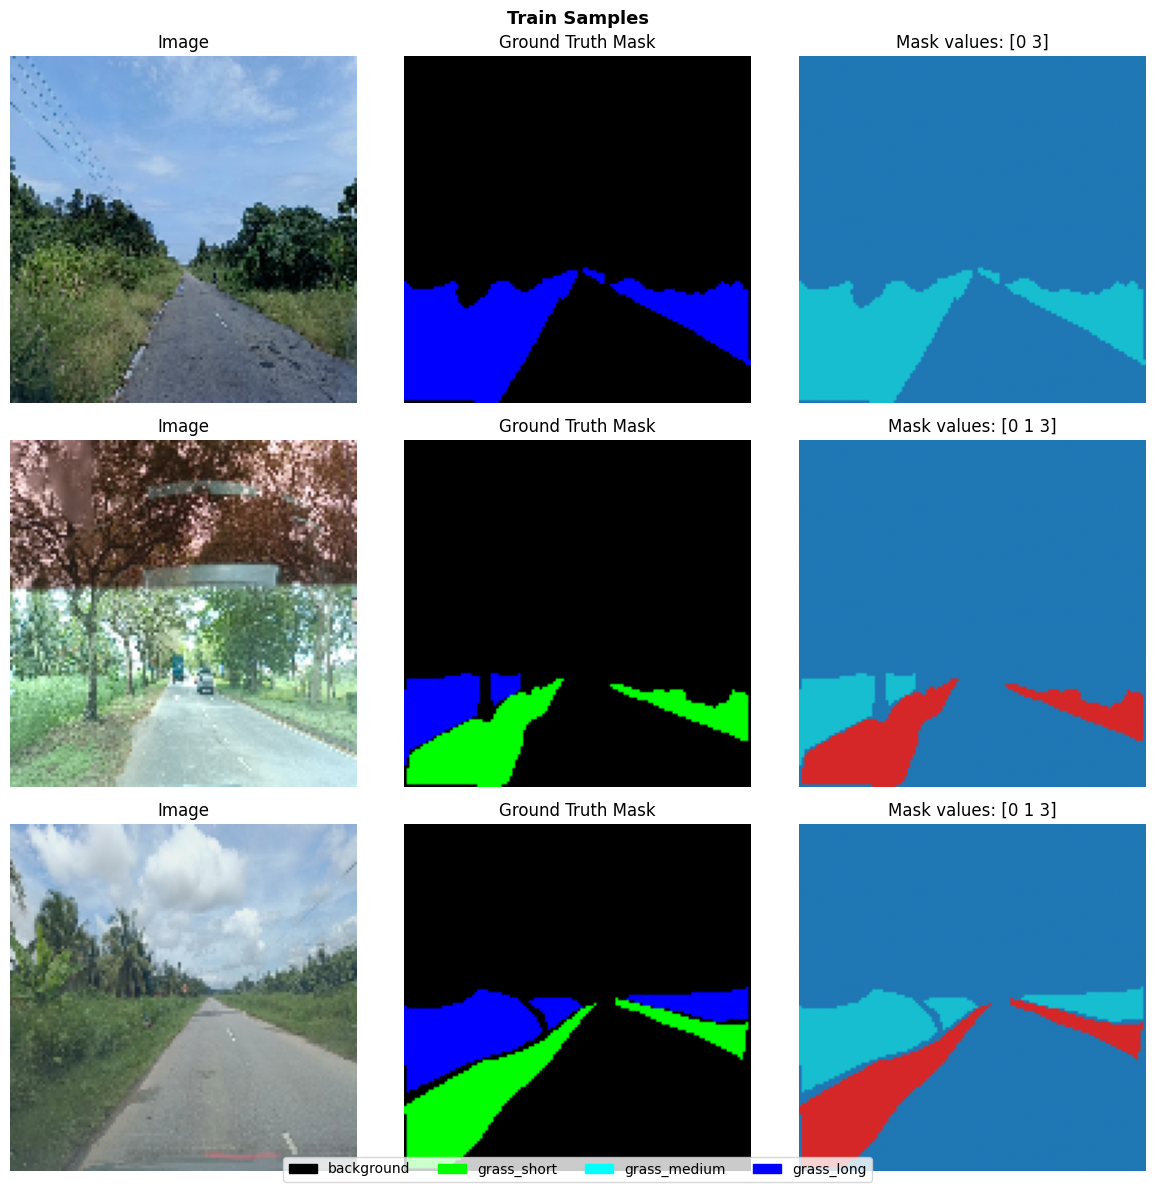

In [14]:
# Visualize samples
CLASS_COLORS = {
    0: [0,   0,   0],    # background  black
    1: [0,   255, 0],    # grass_short green
    2: [0,   255, 255],  # grass_medium yellow
    3: [0,   0,   255],  # grass_long  red
}

def mask_to_rgb(mask):
    mask  = np.squeeze(mask.numpy())
    rgb   = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in CLASS_COLORS.items():
        rgb[mask == class_id] = color
    return rgb

def show_samples(dataset, n=3, title="Samples"):
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for images, masks in dataset.take(1):
        for i in range(min(n, len(images))):
            axes[i][0].imshow(images[i].numpy())
            axes[i][0].set_title("Image")
            axes[i][0].axis("off")

            axes[i][1].imshow(mask_to_rgb(masks[i]))
            axes[i][1].set_title("Ground Truth Mask")
            axes[i][1].axis("off")

            # Show mask raw values
            unique = np.unique(masks[i].numpy())
            axes[i][2].imshow(masks[i].numpy().squeeze(), cmap="tab10", vmin=0, vmax=3)
            axes[i][2].set_title(f"Mask values: {unique}")
            axes[i][2].axis("off")

    # Legend
    patches = [mpatches.Patch(color=np.array(c)/255, label=CLASS_NAMES[k])
               for k, c in CLASS_COLORS.items()]
    fig.legend(handles=patches, loc="lower center", ncol=4)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "sample_images.png"), dpi=150)
    plt.show()

show_samples(train_dataset, n=3, title="Train Samples")

In [15]:
# BUILD MODEL
def build_unet_mobilenetv2(img_size, num_classes):

    # ---- ENCODER: MobileNetV2 pretrained on ImageNet ----
    base_model = tf.keras.applications.MobileNetV2(
        input_shape = img_size + (3,),
        include_top = False,
        weights     = "imagenet"    # pretrained weights
    )

    # Freeze encoder
    base_model.trainable = False

    # Skip connection layers from MobileNetV2
    skip_layer_names = [
        "block_1_expand_relu",    # 64x64
        "block_3_expand_relu",    # 32x32
        "block_6_expand_relu",    # 16x16
        "block_13_expand_relu",   # 8x8
        "block_16_project",       # 4x4  (bottleneck)
    ]

    # Extract skip connection outputs
    skip_outputs = [base_model.get_layer(name).output for name in skip_layer_names]
    encoder      = Model(inputs=base_model.input, outputs=skip_outputs, name="mobilenetv2_encoder")

    # ---- DECODER: Upsampling with skip connections ----
    inputs  = layers.Input(shape=img_size + (3,), name="input_image")
    skips   = encoder(inputs)
    x       = skips[-1]           # start from bottleneck
    skips_reversed = list(reversed(skips[:-1]))

    decoder_filters = [512, 256, 128, 64]

    for filters, skip in zip(decoder_filters, skips_reversed):
        # Upsample
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # Skip connection
        x = layers.Concatenate()([x, skip])

        # Refine
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

    # Final upsample to original size
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Output layer — softmax over num_classes
    outputs = layers.Conv2D(num_classes, 1, activation="softmax", name="output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="unet_mobilenetv2")
    return model, base_model


model, base_model = build_unet_mobilenetv2(IMG_SIZE, NUM_CLASSES)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "unet_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_encoder │ [(None, 64, 64,   │  1,841,984 │ input_image[0][0] │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 32, 144), (None,  │            │                   │
│                     │ 16, 16, 192),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 4, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 512) │  1,475,072 │ mobilenetv2_enco… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 512) │      2,048 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8,      │          0 │ re_lu[0][0],      │
│ (Concatenate)       │ 1088)             │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 512) │  5,014,016 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │  1,179,904 │ re_lu_2[0][0]     │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ re_lu_3[0][0],    │
│ (Concatenate)       │ 448)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │  1,032,448 │ concatenate_1[0]

 Total params: 14,482,596 (55.25 MB)

 Trainable params: 12,634,788 (48.20 MB)

 Non-trainable params: 1,847,808 (7.05 MB)

In [16]:
class MeanIoUWrapper(tf.keras.metrics.MeanIoU):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.argmax(y_pred, axis=-1)
        return super().update_state(y_true, y_pred, sample_weight)

In [18]:
base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        MeanIoUWrapper(num_classes=NUM_CLASSES, name="mean_iou")
    ]
)

# ---- Define these before model.fit ----
STEPS_PER_EPOCH  = len(train_img_paths) // BATCH_SIZE
VALIDATION_STEPS = len(val_img_paths)   // BATCH_SIZE

checkpoint_path = os.path.join(MODEL_DIR, "unet_best.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath       = checkpoint_path,
        monitor        = "val_mean_iou",
        mode           = "max",
        save_best_only = True,
        verbose        = 1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_mean_iou",
        mode                 = "max",
        patience             = 10,
        verbose              = 1,
        restore_best_weights = True
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir = LOG_DIR
    )
]

# Run training
history = model.fit(
    train_dataset,
    epochs           = EPOCHS,
    steps_per_epoch  = STEPS_PER_EPOCH,
    validation_data  = val_dataset,
    validation_steps = VALIDATION_STEPS,
    callbacks        = callbacks
)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.7995 - loss: 0.7714 - mean_iou: 0.2407
Epoch 1: val_mean_iou improved from -inf to 0.23532, saving model to /content/grass-seg/models/unet_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 142s 534ms/step - accuracy: 0.8001 - loss: 0.7702 - mean_iou: 0.2411 - val_accuracy: 0.9274 - val_loss: 0.6311 - val_mean_iou: 0.2353
Epoch 2/20
  1/149 ━━━━━━━━━━━━━━━━━━━━ 1:31:40 37s/step - accuracy: 0.9518 - loss: 0.3499 - mean_iou: 0.3346

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_mean_iou improved from 0.23532 to 0.23662, saving model to /content/grass-seg/models/unet_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 275ms/step - accuracy: 0.9518 - loss: 0.3499 - mean_iou: 0.3346 - val_accuracy: 0.9282 - val_loss: 0.6254 - val_mean_iou: 0.2366
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9487 - loss: 0.3276 - mean_iou: 0.3514
Epoch 3: val_mean_iou improved from 0.23662 to 0.33670, saving model to /content/grass-seg/models/unet_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 140s 515ms/step - accuracy: 0.9487 - loss: 0.3275 - mean_iou: 0.3515 - val_accuracy: 0.9484 - val_loss: 0.3045 - val_mean_iou: 0.3367
Epoch 4/20
  1/149 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - accuracy: 0.9467 - loss: 0.2753 - mean_iou: 0.3711
Epoch 4: val_mean_iou improved from 0.33670 to 0.34171, saving model to /content/grass-seg/models/unet_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.9467 - loss: 0.2753 - mean_iou: 0.3711 - val_accuracy: 0.949

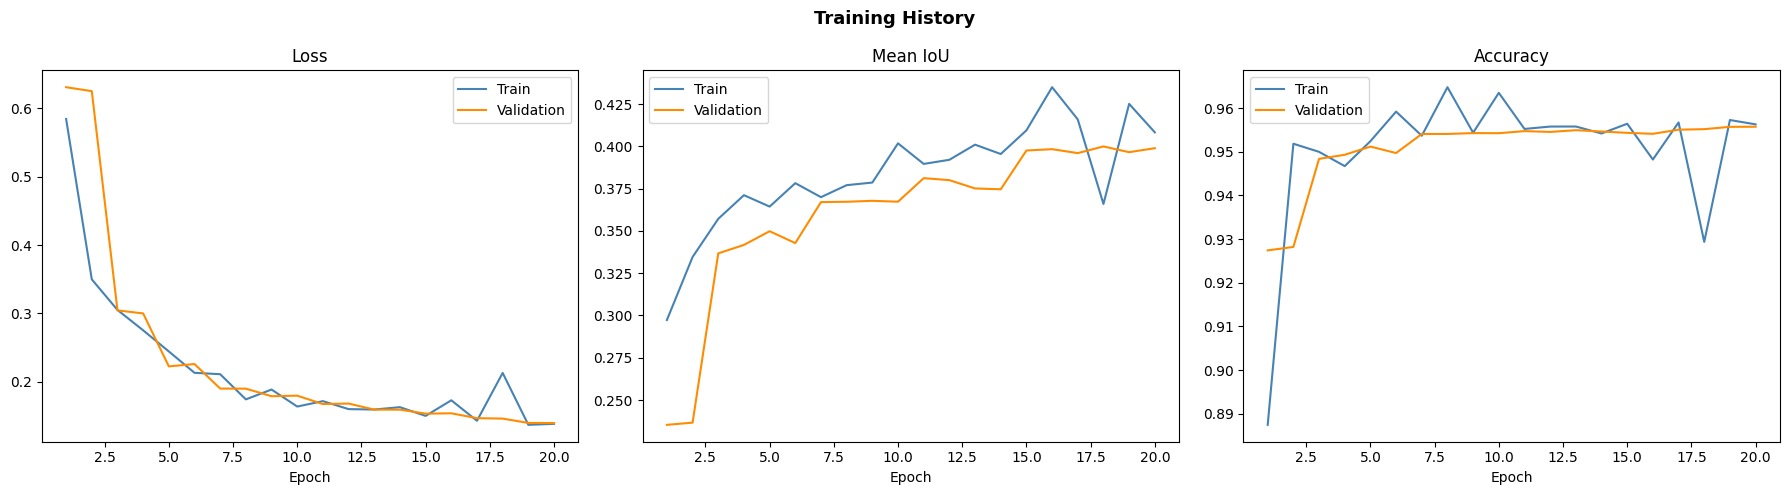

Saved : /content/grass-seg/results/training_history.png


In [19]:
# Plot training history
def plot_history(history):
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    iou      = history.history["mean_iou"]
    val_iou  = history.history["val_mean_iou"]
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]

    epochs_total = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training History", fontsize=13, fontweight="bold")

    for ax, tr, va, title in zip(
        axes,
        [loss,     iou,        acc],
        [val_loss, val_iou,    val_acc],
        ["Loss",   "Mean IoU", "Accuracy"]
    ):
        ax.plot(epochs_total, tr, label="Train",      color="steelblue")
        ax.plot(epochs_total, va, label="Validation", color="darkorange")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()

    plt.tight_layout()
    path = os.path.join(RESULT_DIR, "training_history.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved : {path}")

plot_history(history)

In [20]:
# Load best model and evaluate
print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

best_model = tf.keras.models.load_model(
    checkpoint_path,
    custom_objects={"MeanIoUWrapper": MeanIoUWrapper}
)

results = best_model.evaluate(test_dataset, verbose=1)
print(f"\n  Test Loss     : {results[0]:.4f}")
print(f"  Test Accuracy : {results[1]:.4f}")
print(f"  Test Mean IoU : {results[2]:.4f}")


FINAL EVALUATION ON TEST SET
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9536 - loss: 0.1511 - mean_iou: 0.4047

  Test Loss     : 0.1468
  Test Accuracy : 0.9554
  Test Mean IoU : 0.4096


In [21]:
print("\n===== PER CLASS IoU =====")

all_preds = []
all_masks = []

for images, masks in test_dataset:
    preds = best_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=-1)
    masks = masks.numpy().squeeze(axis=-1)
    all_preds.append(preds)
    all_masks.append(masks)

all_preds = np.concatenate(all_preds, axis=0)
all_masks = np.concatenate(all_masks, axis=0)

def compute_iou(preds, masks, class_id):
    pred_c       = (preds == class_id)
    mask_c       = (masks == class_id)
    intersection = np.logical_and(pred_c, mask_c).sum()
    union        = np.logical_or(pred_c,  mask_c).sum()
    if union == 0:
        return float("nan")
    return intersection / union

print(f"\n  {'Class':<5} {'Name':<15} {'IoU':>8}  Status")
print(f"  {'-'*45}")

iou_scores = {}
for class_id, name in CLASS_NAMES.items():
    iou = compute_iou(all_preds, all_masks, class_id)
    iou_scores[name] = iou
    if np.isnan(iou):
        status = "NOT PRESENT"
    elif iou >= 0.7:
        status = "GOOD"
    elif iou >= 0.5:
        status = "ACCEPTABLE"
    else:
        status = "POOR"
    print(f"  {class_id:<5} {name:<15} {iou:>8.4f}  {status}")

valid_ious = [v for v in iou_scores.values() if not np.isnan(v)]
mean_iou   = np.mean(valid_ious)
print(f"\n  Mean IoU (mIoU) : {mean_iou:.4f}")


===== PER CLASS IoU =====

  Class Name                 IoU  Status
  ---------------------------------------------
  0     background        0.9692  GOOD
  1     grass_short       0.5237  ACCEPTABLE
  2     grass_medium      0.1031  POOR
  3     grass_long        0.0422  POOR

  Mean IoU (mIoU) : 0.4096


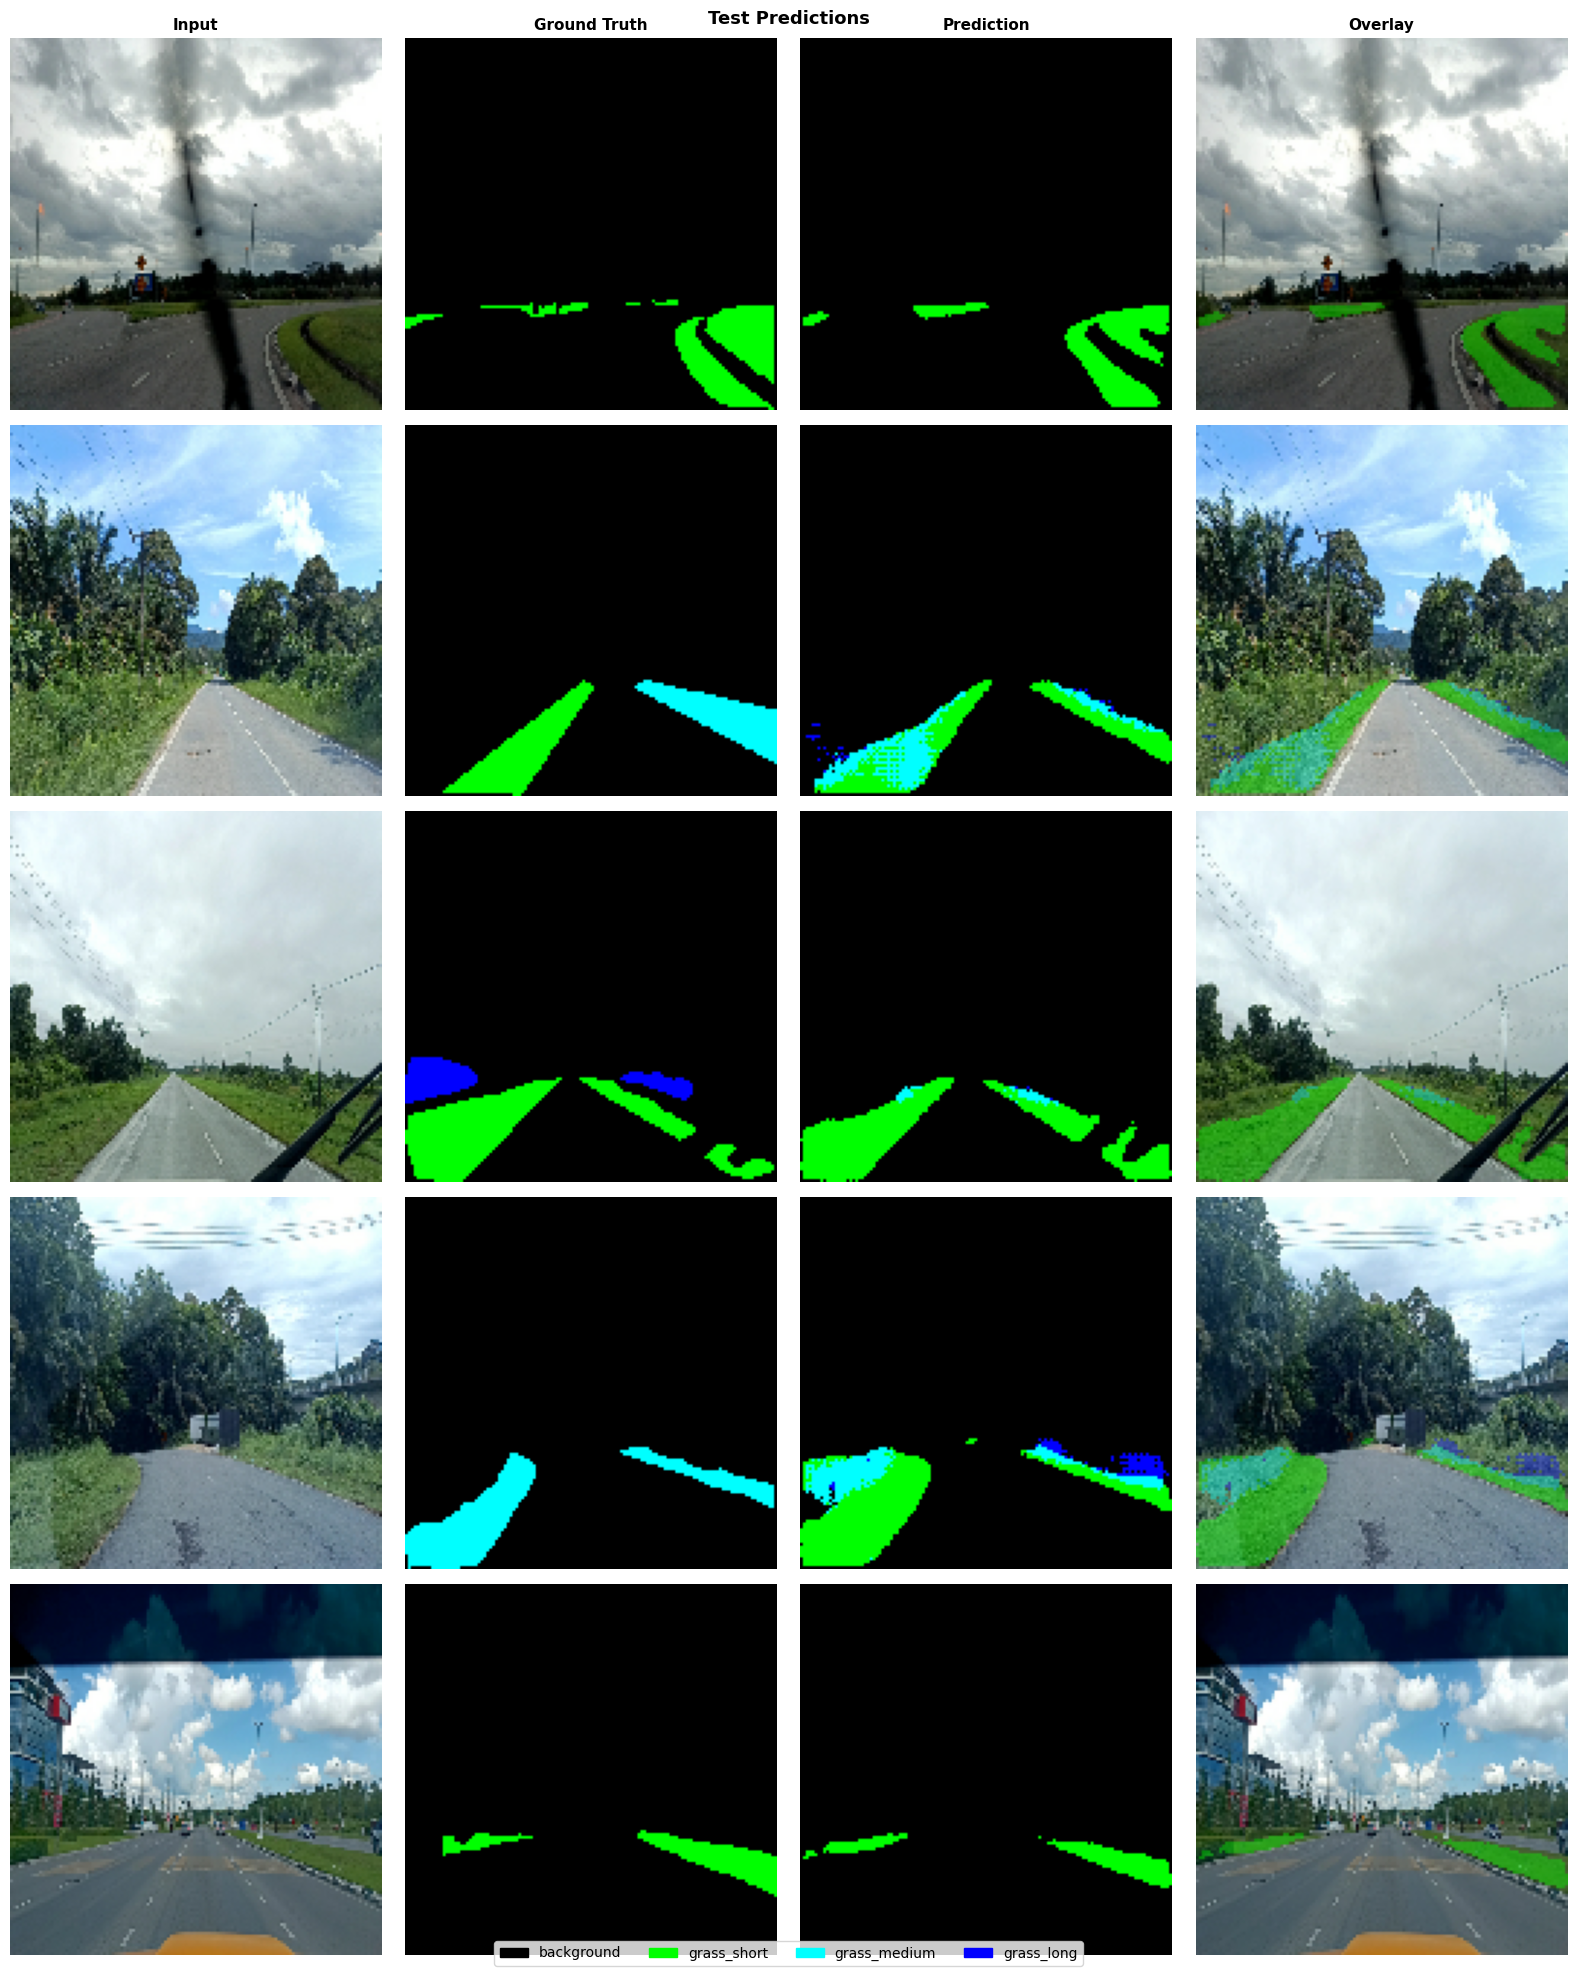

Saved : /content/grass-seg/results/test_predictions.png

COMPLETE

  Model    : /content/grass-seg/models/unet_best.keras
  Report   : /content/grass-seg/results/evaluation_report.json
  Plots    : /content/grass-seg/results

  Test Loss     : 0.1468
  Test Accuracy : 0.9554
  Test Mean IoU : 0.4096

  Per Class IoU:
    background      : 0.9692
    grass_short     : 0.5237
    grass_medium    : 0.1031
    grass_long      : 0.0422


In [23]:
def show_predictions(dataset, model, n=5):
    fig, axes = plt.subplots(n, 4, figsize=(16, n * 4))
    fig.suptitle("Test Predictions", fontsize=13, fontweight="bold")

    for ax, title in zip(axes[0], ["Input", "Ground Truth", "Prediction", "Overlay"]):
        ax.set_title(title, fontsize=11, fontweight="bold")

    count = 0
    for images, masks in dataset:
        if count >= n:
            break
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=-1)

        for i in range(len(images)):
            if count >= n:
                break

            img       = images[i].numpy()
            gt_mask   = masks[i].numpy().squeeze()
            pred_mask = preds[i]

            # Ground truth RGB
            gt_rgb = np.zeros((*gt_mask.shape, 3), dtype=np.uint8)
            for cid, color in CLASS_COLORS.items():
                gt_rgb[gt_mask == cid] = color

            # Prediction RGB
            pred_rgb = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
            for cid, color in CLASS_COLORS.items():
                pred_rgb[pred_mask == cid] = color

            # Overlay on original image
            overlay = (img * 255).astype(np.uint8).copy()
            alpha   = 0.4
            for cid, color in CLASS_COLORS.items():
                if cid == 0:
                    continue
                region          = pred_mask == cid
                overlay[region] = (
                    overlay[region] * (1 - alpha) +
                    np.array(color) * alpha
                ).astype(np.uint8)

            axes[count][0].imshow(img);      axes[count][0].axis("off")
            axes[count][1].imshow(gt_rgb);   axes[count][1].axis("off")
            axes[count][2].imshow(pred_rgb); axes[count][2].axis("off")
            axes[count][3].imshow(overlay);  axes[count][3].axis("off")
            count += 1

    patches = [mpatches.Patch(color=np.array(c)/255, label=CLASS_NAMES[k])
               for k, c in CLASS_COLORS.items()]
    fig.legend(handles=patches, loc="lower center", ncol=4)
    plt.tight_layout()
    path = os.path.join(RESULT_DIR, "test_predictions.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved : {path}")

show_predictions(test_dataset, best_model, n=5)

# ============================================================
# CELL 18 — SAVE REPORT
# ============================================================

report = {
    "generated_at" : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model"        : "UNet with MobileNetV2 encoder",
    "config"       : {
        "img_size"   : list(IMG_SIZE),
        "num_classes": NUM_CLASSES,
        "batch_size" : BATCH_SIZE,
        "epochs"     : EPOCHS,
        "loss"       : "SparseCategoricalCrossentropy"
    },
    "dataset"      : {
        "train" : len(train_img_paths),
        "val"   : len(val_img_paths),
        "test"  : len(test_img_paths)
    },
    "test_results" : {
        "loss"     : round(float(results[0]), 4),
        "accuracy" : round(float(results[1]), 4),
        "mean_iou" : round(float(mean_iou),   4)
    },
    "per_class_iou": {
        name: round(float(iou), 4) if not np.isnan(iou) else None
        for name, iou in iou_scores.items()
    }
}

report_path = os.path.join(RESULT_DIR, "evaluation_report.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=4)

print("\n" + "="*60)
print("COMPLETE")
print("="*60)
print(f"\n  Model    : {checkpoint_path}")
print(f"  Report   : {report_path}")
print(f"  Plots    : {RESULT_DIR}")
print(f"\n  Test Loss     : {results[0]:.4f}")
print(f"  Test Accuracy : {results[1]:.4f}")
print(f"  Test Mean IoU : {mean_iou:.4f}")
print(f"\n  Per Class IoU:")
for name, iou in iou_scores.items():
    if not np.isnan(iou):
        print(f"    {name:<15} : {iou:.4f}")